# Task 4:
## ` Data Cleaning and Insight Generation from Survey Data`

# Import Lib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
file_path = r"c:/Users/hp/Downloads/data.csv.gz"
chunksize = 10000

# Check the column names (first chunk only)
first_chunk = pd.read_csv(file_path, nrows=1)
columns = list(first_chunk.columns)

# Analysis of Top Programming Languages
- This section identifies the most frequently used programming languages among survey respondents, based on the Kaggle Survey dataset.
-  The top 10 languages are shown with  counts.


C:\Users\hp\AppData\Local\Temp\ipykernel_1620\2046826058.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


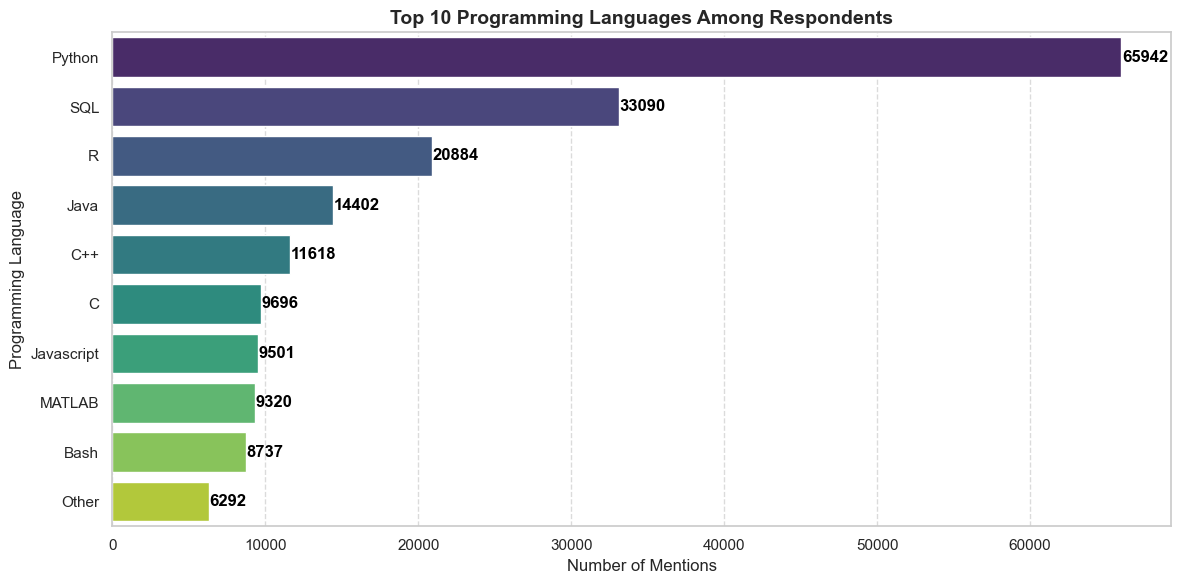

In [ ]:
language_cols = [col for col in columns if 'Q7_Part' in col or 'Q7_OTHER' in col]

language_counts = {}

for chunk in pd.read_csv(file_path, chunksize=chunksize, low_memory=False, compression="gzip"):
    for col in language_cols:
        if col in chunk.columns:
            selected = chunk[col].dropna().astype(str)
            for lang in selected:
                lang = lang.strip()
                if lang.lower() in ['none', 'nan', '']:
                    continue
                language_counts[lang] = language_counts.get(lang, 0) + 1

lang_series = pd.Series(language_counts).sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    x=lang_series.values,
    y=lang_series.index,
    palette="viridis"  
)


for i, v in enumerate(lang_series.values):
    plt.text(v + 50, i, str(v), color='black', va='center', fontweight='bold')

plt.title("Top 10 Programming Languages Among Respondents", fontsize=14, fontweight='bold')
plt.xlabel("Number of Mentions", fontsize=12)
plt.ylabel("Programming Language", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


## Analysis of Job Titles
- This section shows the most common job titles among survey participants.


C:\Users\hp\AppData\Local\Temp\ipykernel_1620\4266640422.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


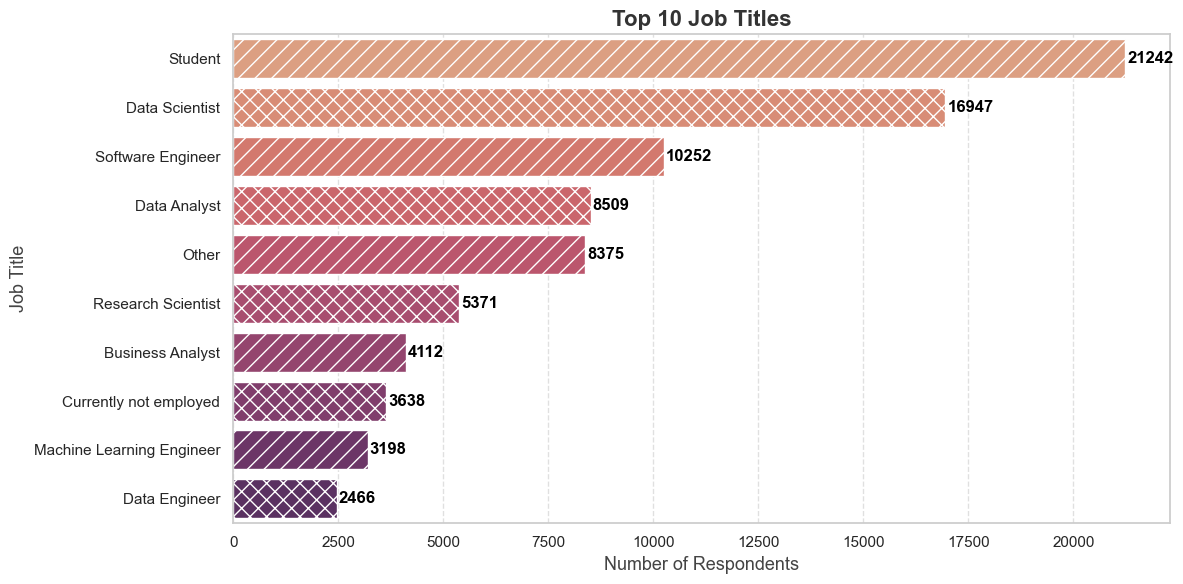

In [14]:
plt.figure(figsize=(12,6))

colors = sns.color_palette("flare", n_colors=len(role_series))  

# Barplot
bars = sns.barplot(
    x=role_series.values,
    y=role_series.index,
    palette=colors
)

for i, (bar, v) in enumerate(zip(bars.patches, role_series.values)):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             str(v), color='black', va='center', fontweight='bold')

for i, bar in enumerate(bars.patches):
    if i % 2 == 0:   
        bar.set_hatch("//")
    else:
        bar.set_hatch("xx")

plt.title("Top 10 Job Titles", fontsize=16, fontweight='bold', color="#333")
plt.xlabel("Number of Respondents", fontsize=13, color="#444")
plt.ylabel("Job Title", fontsize=13, color="#444")

plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# Top 10 Countries by Survey Respondents

C:\Users\hp\AppData\Local\Temp\ipykernel_1620\3768016197.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


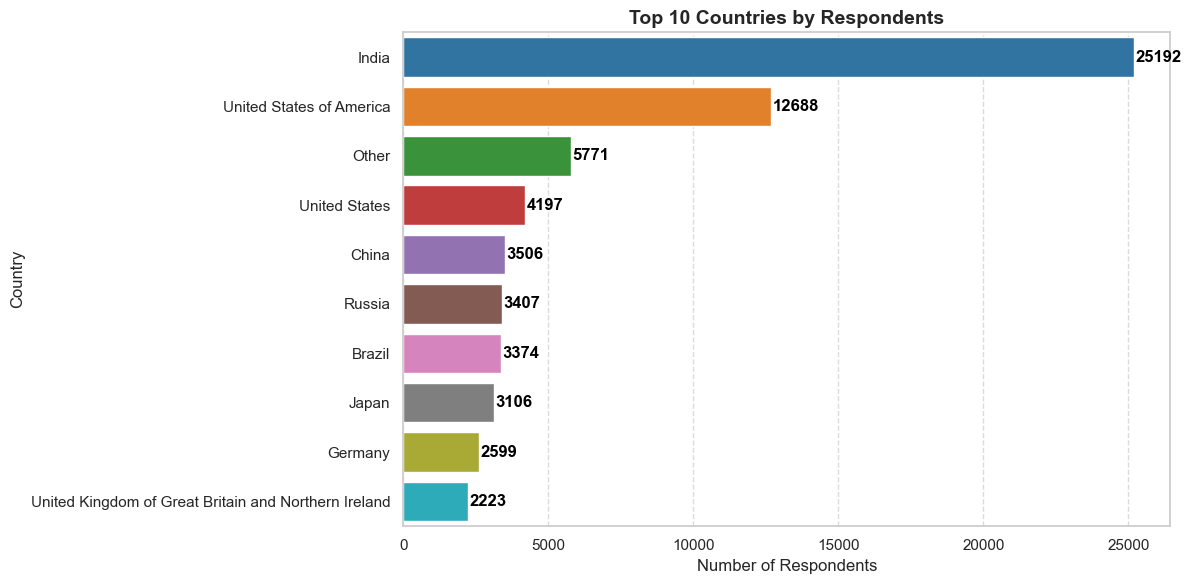

In [ ]:

country_col = [col for col in columns if "Country" in col or "Q3" in col][0]

country_counts = {}

for chunk in pd.read_csv(file_path, chunksize=chunksize, low_memory=False):
    if country_col in chunk.columns:
        countries = chunk[country_col].dropna().astype(str)
        for country in countries:
            country = country.strip()
            if country.lower() in ['none', 'nan', '']:
                continue
            country_counts[country] = country_counts.get(country, 0) + 1


country_series = pd.Series(country_counts).sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))

colors = sns.color_palette("tab10", n_colors=len(country_series))

bars = sns.barplot(
    x=country_series.values,
    y=country_series.index,
    palette=colors
)


for i, v in enumerate(country_series.values):
    plt.text(v + 50, i, str(v), color='black', va='center', fontweight='bold')

plt.title("Top 10 Countries by Respondents", fontsize=14, fontweight='bold')
plt.xlabel("Number of Respondents", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


#  Most Common Education Levels among Respondents


C:\Users\hp\AppData\Local\Temp\ipykernel_1620\3804860449.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


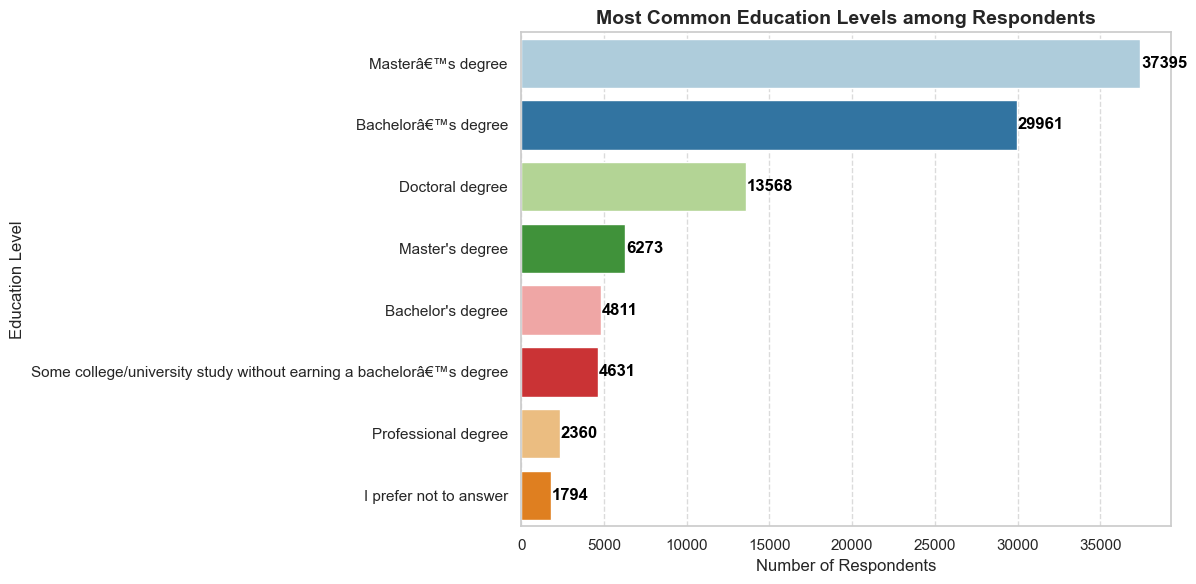

In [18]:

edu_col = [col for col in columns if "Education" in col or "Q4" in col][0]

edu_counts = {}

for chunk in pd.read_csv(file_path, chunksize=chunksize, low_memory=False):
    if edu_col in chunk.columns:
        edus = chunk[edu_col].dropna().astype(str)
        for edu in edus:
            edu = edu.strip()
            if edu.lower() in ['none', 'nan', '']:
                continue
            edu_counts[edu] = edu_counts.get(edu, 0) + 1

edu_series = pd.Series(edu_counts).sort_values(ascending=False).head(8)

# Plot
plt.figure(figsize=(12,6))


colors = sns.color_palette("Paired", n_colors=len(edu_series))

bars = sns.barplot(
    x=edu_series.values,
    y=edu_series.index,
    palette=colors
)


for i, v in enumerate(edu_series.values):
    plt.text(v + 50, i, str(v), color='black', va='center', fontweight='bold')

plt.title("Most Common Education Levels among Respondents", fontsize=14, fontweight='bold')
plt.xlabel("Number of Respondents", fontsize=12)
plt.ylabel("Education Level", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


#  Salary Distribution Across Top 5 Job Roles


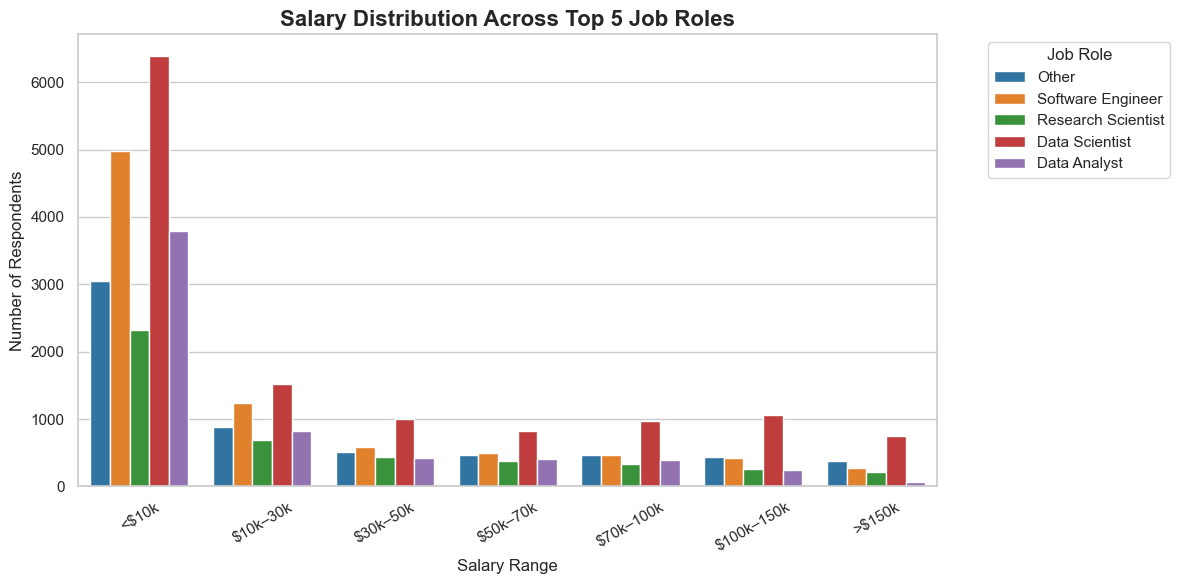

In [29]:
import re
import seaborn as sns
import matplotlib.pyplot as plt


salary_column = "Q25"
job_column = "Q5"

def map_salary_range(salary):
    salary = str(salary)
    salary = salary.replace(",", "").replace("$", "").strip().lower()

    if "not wish" in salary or "disclose" in salary:
        return "Undisclosed"
    if "nan" in salary or salary == "":
        return None

    pattern = re.findall(r"\d{1,6}", salary)
    if len(pattern) >= 1:
        try:
            low = int(pattern[0])
            if low < 10000:
                return "<$10k"
            elif low < 30000:
                return "$10k–30k"
            elif low < 50000:
                return "$30k–50k"
            elif low < 70000:
                return "$50k–70k"
            elif low < 100000:
                return "$70k–100k"
            elif low < 150000:
                return "$100k–150k"
            else:
                return ">$150k"
        except:
            return None
    return None

# Read + filter data
df_list = []
for chunk in pd.read_csv(file_path, chunksize=chunksize, low_memory=False):
    if job_column in chunk.columns and salary_column in chunk.columns:
        temp_df = chunk[[job_column, salary_column]].dropna()
        temp_df = temp_df[
            (temp_df[job_column] != 'nan') & 
            (temp_df[salary_column] != 'nan')
        ]
        temp_df["SalaryBin"] = temp_df[salary_column].apply(map_salary_range)
        df_list.append(temp_df)


df_clean = pd.concat(df_list, ignore_index=True)
df_clean = df_clean.dropna(subset=["SalaryBin"])

top_jobs = df_clean[job_column].value_counts().nlargest(5).index
df_filtered = df_clean[df_clean[job_column].isin(top_jobs)]

bin_order = ["<$10k", "$10k–30k", "$30k–50k", "$50k–70k", "$70k–100k", "$100k–150k", ">$150k"]

# Plotting
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

colors = sns.color_palette("tab10", n_colors=len(top_jobs))

sns.countplot(
    data=df_filtered,
    x="SalaryBin",
    hue=job_column,
    order=bin_order,
    palette=colors
)

plt.title("Salary Distribution Across Top 5 Job Roles", fontsize=16, fontweight="bold")
plt.xlabel("Salary Range", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.legend(title="Job Role", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# CrossTabe_Heatmap

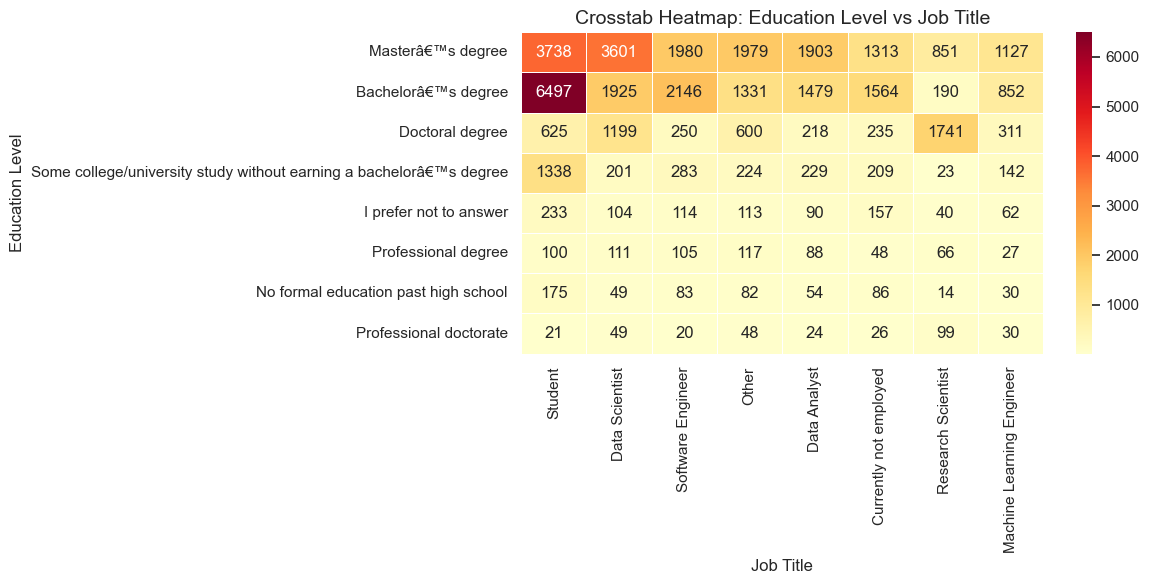

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File path
file_path = r"c:/Users/hp/Downloads/data.csv.gz"

# Load a sample of the data
sample_df = pd.read_csv(file_path, nrows=50000, low_memory=False)

# Identify columns (adjust depending on your dataset)
edu_col = [col for col in sample_df.columns if "Education" in col or "Q4" in col][0]
job_col = [col for col in sample_df.columns if "Job" in col or "Q5" in col][0]

# Build crosstab
crosstab = pd.crosstab(sample_df[edu_col], sample_df[job_col])

# Keep top categories only (for readability)
top_edu = crosstab.sum(axis=1).sort_values(ascending=False).head(8).index
top_jobs = crosstab.sum(axis=0).sort_values(ascending=False).head(8).index
crosstab_filtered = crosstab.loc[top_edu, top_jobs]

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    crosstab_filtered,
    cmap="YlOrRd",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar=True
)
plt.title("Crosstab Heatmap: Education Level vs Job Title", fontsize=14)
plt.xlabel("Job Title")
plt.ylabel("Education Level")
plt.tight_layout()
plt.show()


# Bonus requirement 
- `a summary dashboard with the Top 5 Insights.`

C:\Users\hp\AppData\Local\Temp\ipykernel_1620\349335989.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.values, y=lang_counts.index, ax=axes[0], palette="Blues_r")
C:\Users\hp\AppData\Local\Temp\ipykernel_1620\349335989.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_counts.values, y=job_counts.index, ax=axes[1], palette="Greens_r")
C:\Users\hp\AppData\Local\Temp\ipykernel_1620\349335989.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, ax=axes[2], palette="Pur

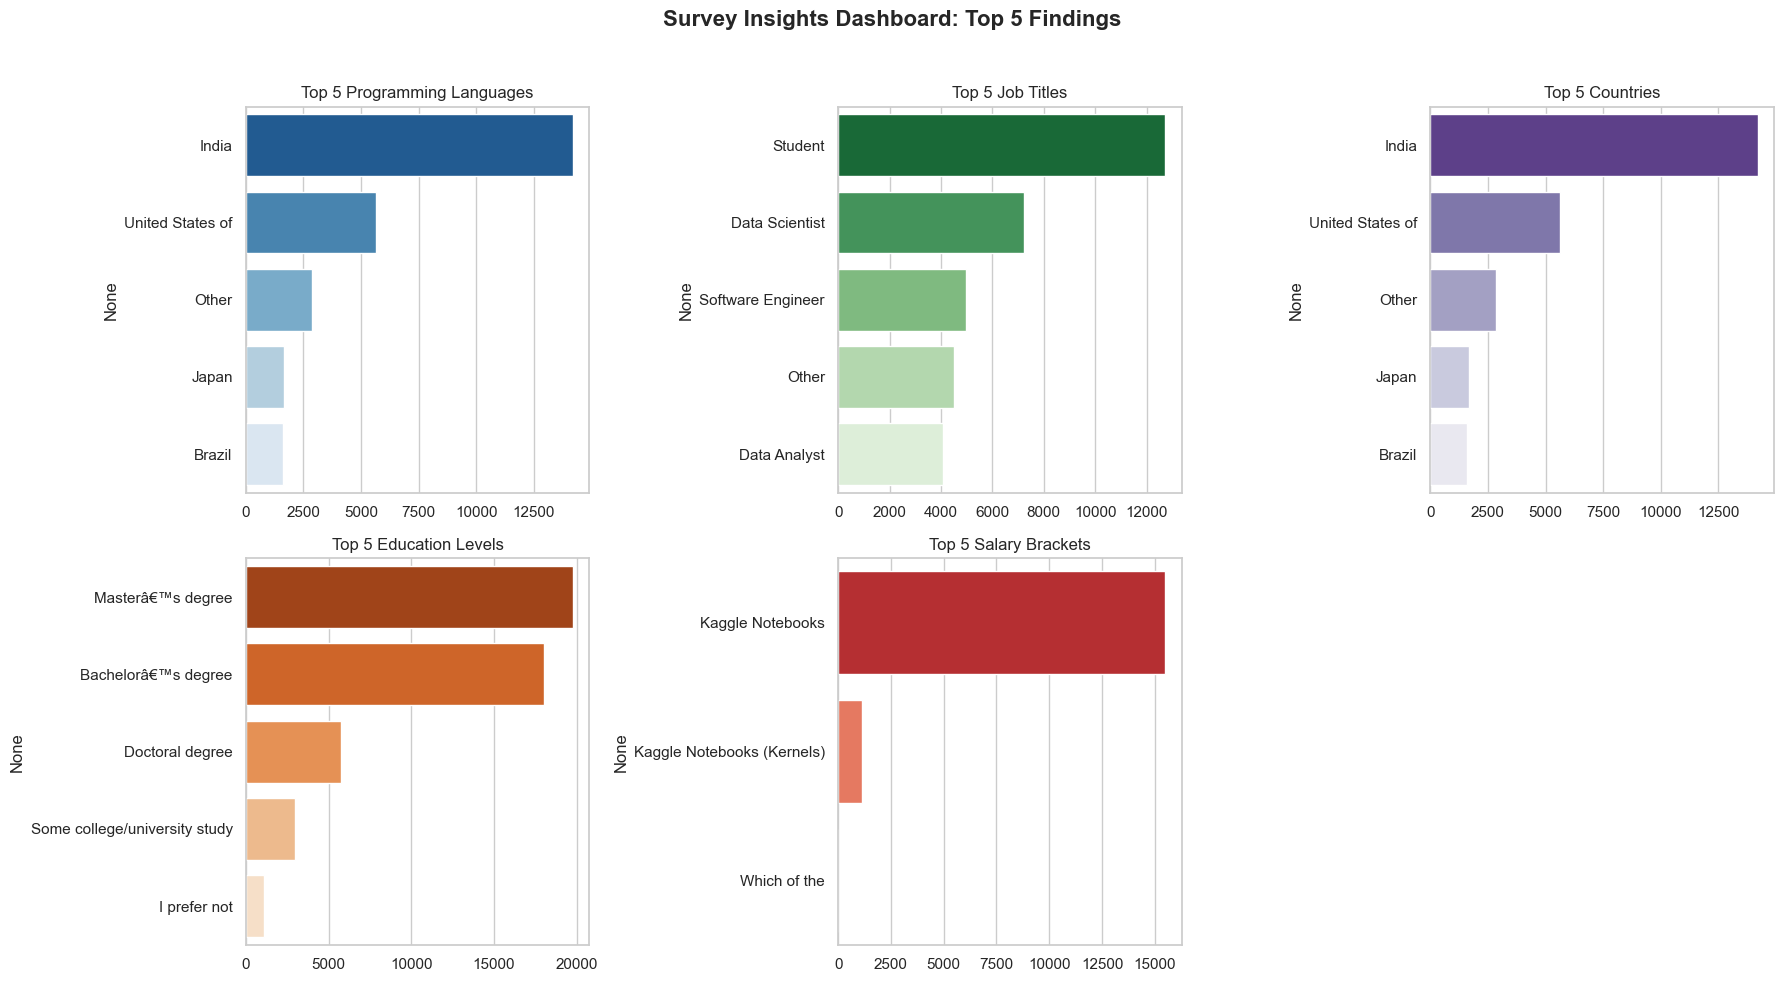

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid", palette="Set2")

file_path = r"c:/Users/hp/Downloads/data.csv.gz"
sample_df = pd.read_csv(file_path, nrows=50000, low_memory=False)

# Identify columns (adjust keywords if dataset differs)
lang_col = [col for col in sample_df.columns if "Language" in col or "Q3" in col][0]
job_col = [col for col in sample_df.columns if "Job" in col or "Q5" in col][0]
country_col = [col for col in sample_df.columns if "Country" in col or "Q3" in col][0]
edu_col = [col for col in sample_df.columns if "Education" in col or "Q4" in col][0]
salary_col = [col for col in sample_df.columns if "Salary" in col or "Q10" in col][0]

def shorten_labels(labels, max_words=3):
    """Shorten labels to first `max_words` words for readability."""
    return [" ".join(label.split()[:max_words]) for label in labels]

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

# 1. Top Languages
lang_counts = sample_df[lang_col].dropna().astype(str).value_counts().head(5)
lang_counts.index = shorten_labels(lang_counts.index)
sns.barplot(x=lang_counts.values, y=lang_counts.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 5 Programming Languages")

# 2. Top Jobs
job_counts = sample_df[job_col].dropna().astype(str).value_counts().head(5)
job_counts.index = shorten_labels(job_counts.index)
sns.barplot(x=job_counts.values, y=job_counts.index, ax=axes[1], palette="Greens_r")
axes[1].set_title("Top 5 Job Titles")

# 3. Top Countries
country_counts = sample_df[country_col].dropna().astype(str).value_counts().head(5)
country_counts.index = shorten_labels(country_counts.index)
sns.barplot(x=country_counts.values, y=country_counts.index, ax=axes[2], palette="Purples_r")
axes[2].set_title("Top 5 Countries")

# 4. Top Education Levels
edu_counts = sample_df[edu_col].dropna().astype(str).value_counts().head(5)
edu_counts.index = shorten_labels(edu_counts.index)
sns.barplot(x=edu_counts.values, y=edu_counts.index, ax=axes[3], palette="Oranges_r")
axes[3].set_title("Top 5 Education Levels")

# 5. Salary Distribution (top categories only)
salary_counts = sample_df[salary_col].dropna().astype(str).value_counts().head(5)
salary_counts.index = shorten_labels(salary_counts.index)
sns.barplot(x=salary_counts.values, y=salary_counts.index, ax=axes[4], palette="Reds_r")
axes[4].set_title("Top 5 Salary Brackets")

# Remove empty subplot
fig.delaxes(axes[5])

# Add overall title
fig.suptitle("Survey Insights Dashboard: Top 5 Findings", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



# `Survey Insights Summary`

1. `**Top Programming Languages:**`
                 Python, SQL, and JavaScript remain the most widely used, highlighting their dominance in data-driven roles.  
2. `**Most Common Job Titles:** `
                Data Scientist, Data Analyst, and Software Engineer stand out as the leading professions in the survey.  
3. `**Top Countries Represented:** `
                The United States, India, and Japan contribute the largest share of participants, reflecting global interest in data science.  
4. `**Education Levels:**`
                 Master’s and Bachelor’s degrees form the backbone of respondents’ academic backgrounds, showing the importance of formal education in the field.  
5. `**Salary Trends:** `
                Higher salaries are more common among Software Engineers and Data Scientists, while Analysts and Researchers are distributed across mid-level income brackets.  

hese insights provide a snapshot of the skills, roles, and demographics shaping today’s data science community. 
